## Procedimiento de modelado de imagenes

### Preparacion de imagenes

In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models

BATCH_SIZE = 100

def load_image(img_path, size=(32, 32)):
    label = tf.constant(1, tf.int8) if tf.strings.regex_full_match(img_path, ".*automobile.*")\
            else tf.constant(8, tf.int8)
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img)
    img = tf.image.resize(img, size) / 255.0
    return(img, label)

In [2]:
ds_train = tf.data.Dataset.list_files("../data/cifar2/train/*/*.jpg")\
        .map(load_image, num_parallel_calls=tf.data.experimental.AUTOTUNE)\
        .shuffle(buffer_size=1000).batch(BATCH_SIZE)\
        .prefetch(tf.data.experimental.AUTOTUNE)

ds_test = tf.data.Dataset.list_files("../data/cifar2/test/*/*.jpg")\
        .map(load_image, num_parallel_calls=tf.data.experimental.AUTOTUNE)\
        .batch(BATCH_SIZE)\
        .prefetch(tf.data.experimental.AUTOTUNE)

2021-12-19 15:31:55.596362: I tensorflow/core/platform/cpu_feature_guard.cc:151] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2021-12-19 15:31:55.599298: I tensorflow/core/common_runtime/process_util.cc:146] Creating new thread pool with default inter op setting: 2. Tune using inter_op_parallelism_threads for best performance.


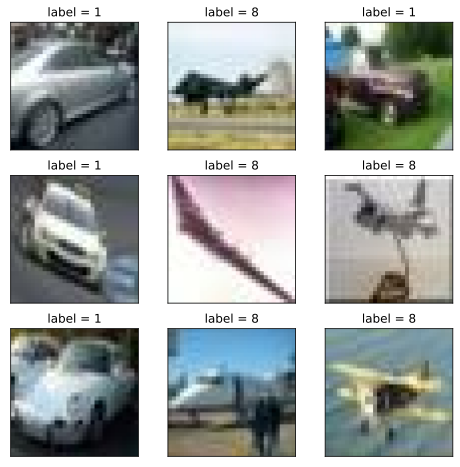

In [3]:
%matplotlib inline
%config InlineBackend.figure_format = 'svg'

from matplotlib import pyplot as plt 

plt.figure(figsize=(8,8)) 
for i,(img,label) in enumerate(ds_train.unbatch().take(9)):
    ax=plt.subplot(3,3,i+1)
    ax.imshow(img.numpy())
    ax.set_title("label = %d"%label)
    ax.set_xticks([])
    ax.set_yticks([]) 
plt.show()


### Definicion del modelo


In [4]:
tf.keras.backend.clear_session()

inputs = layers.Input(shape=(32, 32, 3))
x = layers.Conv2D(32, kernel_size=(3, 3))(inputs)
x = layers.MaxPool2D()(x)
x = layers.Conv2D(64, kernel_size=(5, 5))(x)
x = layers.MaxPool2D()(x)
x = layers.Dropout(rate=0.1)(x)
x = layers.Flatten()(x)
x = layers.Dense(32, activation='relu')(x)
outputs = layers.Dense(1, activation='sigmoid')(x)
model = models.Model(inputs=inputs, outputs=outputs)
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 32, 32, 3)]       0         
                                                                 
 conv2d (Conv2D)             (None, 30, 30, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 15, 15, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 11, 11, 64)        51264     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 5, 5, 64)         0         
 2D)                                                             
                                                                 
 dropout (Dropout)           (None, 5, 5, 64)          0     

### Entrenamiento del modelo

In [5]:
import datetime
from pathlib import Path
stamp = datetime.datetime.now().strftime("%Y%m%d - %H%M%S")
logdir = str(Path('../data/autograph/' + stamp))

tensorboard_callback = tf.keras.callbacks.TensorBoard(logdir, histogram_freq=1)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.binary_crossentropy,
    metrics=["accuracy"]
)

history = model.fit(ds_train, epochs=10, validation_data=ds_test, callbacks=[tensorboard_callback], workers=4)

Epoch 1/10
100/100 [==============================] - 6s 55ms/step - loss: -219540.4062 - accuracy: 0.4998 - val_loss: -1260617.5000 - val_accuracy: 0.5000
Epoch 2/10
100/100 [==============================] - 5s 46ms/step - loss: -9769454.0000 - accuracy: 0.5000 - val_loss: -28495908.0000 - val_accuracy: 0.5000
Epoch 3/10
100/100 [==============================] - 5s 47ms/step - loss: -83351736.0000 - accuracy: 0.5000 - val_loss: -173630336.0000 - val_accuracy: 0.5000
Epoch 4/10
100/100 [==============================] - 6s 61ms/step - loss: -345481472.0000 - accuracy: 0.5000 - val_loss: -599895104.0000 - val_accuracy: 0.5000
Epoch 5/10
100/100 [==============================] - 5s 46ms/step - loss: -989382400.0000 - accuracy: 0.5000 - val_loss: -1533784448.0000 - val_accuracy: 0.5000
Epoch 6/10
100/100 [==============================] - 5s 49ms/step - loss: -2251223808.0000 - accuracy: 0.5000 - val_loss: -3240242176.0000 - val_accuracy: 0.5000
Epoch 7/10
100/100 [====================